<a href="https://colab.research.google.com/github/Anagh19/Complex-Systems-Project/blob/Design-of-Health-Agent%2C-County-Agent%2C-Network-Model/CS7065_DOI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the import from Github for update ease, only need to run once per session

In [26]:
from pathlib import Path

repo_path = Path("/content/Complex-Systems-Project")

if not repo_path.exists():
    !git clone https://github.com/Anagh19/Complex-Systems-Project

%cd /content/Complex-Systems-Project

PROJECT_ROOT = Path.cwd()

Cloning into 'Complex-Systems-Project'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 45 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 2.12 MiB | 5.01 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/Complex-Systems-Project


In [27]:
try:
  import mesa
except:
  !pip install mesa --quiet
  import mesa

try:
  import mesa_geo as mg
except:
  !pip install -U --pre mesa-geo --quiet

try:
  import networkx as nx
except:
  !pip install networkx --quiet
  import networkx as nx

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from shapely.geometry import Point
from mesa.discrete_space import CellCollection, Network, FixedAgent

In [28]:
import shapely.geometry as geom

def create_synthetic_states():
    # Three rectangular states
    states = {
        "A": geom.Polygon([(0,0),(10,0),(10,10),(0,10)]),
        "B": geom.Polygon([(10,0),(20,0),(20,10),(10,10)]),
        "C": geom.Polygon([(0,10),(10,10),(10,20),(0,20)])
    }
    return states

STATE_POLYGONS = create_synthetic_states()
STATE_IDS = list(STATE_POLYGONS.keys()) # A or B or C


In [173]:
class Health_Agent(FixedAgent):
  def __init__(
      self,
      model,
      agent_type, # LOCAL or STATE
      state_id,
      pos, # position i think
      ):
    super().__init__(model)
    self.agent_type = agent_type
    self.state_id = state_id
    self.pos = pos

    self.adopted = False # Inital condition for all agents since the agent is seeded in the model
    self.is_seed = False # Inital condition for all agents since the agent is seeded in the model

  def step(self):
    return print(f"Health Department {self.unique_id} from State {self.state_id}")


In [171]:
class Health_Model(mesa.Model):
  def __init__(
      self,
      num_agents,
      num_of_connections,
      dist_threshold,
      diffusion_mode = "government", # can also be localized
      num_states = 3,
      initial_seed = 1,
      seed_includes_state = False, # while the state can be the seed, its random
      rng=4,
      ):
    super().__init__(rng=rng)


    self.num_agents = num_agents
    self.seed_includes_state = seed_includes_state
    self.num_of_connections = num_of_connections

    self.create_states()
    self.create_local()
    self.choose_seed()
    self.network = nx.Graph()

    for agent in self.state_agents + self.local_agents:
      self.network.add_node(agent.unique_id)
      self.network.nodes[agent.unique_id]['pos'] = agent.pos

    if diffusion_mode == "government":
      self.create_gov_network()
    else:
      self.create_local_network()

    self.datacollector = mesa.DataCollector(
            model_reporters={"Adopters": lambda m: sum(a.adopted for a in m.agents)}
    )


  def create_states(self):
    self.state_agents =[]
    for sid in STATE_IDS:
      poly = STATE_POLYGONS[sid]
      cx, cy = poly.centroid.coords[0]
      pos = (cx + random.uniform(-3,3), cy + random.uniform(-3,3))
      agents = Health_Agent.create_agents(model=self,n=1,agent_type="state", state_id = sid, pos=pos)

      self.state_agents.extend(agents)

  def create_local(self):
    self.local_agents =[]
    for i in range(self.num_agents - len(STATE_IDS)): # desired agents - state agents = # of local agents
      sid = random.choice(STATE_IDS)
      poly = STATE_POLYGONS[sid]
      cx, cy = poly.centroid.coords[0]
      pos = (cx + random.uniform(-3,3), cy + random.uniform(-3,3))
      agents = Health_Agent.create_agents(model=self,n=1,agent_type="local", state_id = sid, pos=pos)

      self.local_agents.extend(agents)

  def create_gov_network(self):
       # State → Local
    for s in self.state_agents:
        for a in self.local_agents:
            if a.state_id == s.state_id:
                self.network.add_edge(s.unique_id, a.unique_id)

    # Local → Local (within same state)
    for sid in STATE_IDS:
        locals_in_state = [a for a in self.local_agents if a.state_id == sid]
        for a in locals_in_state:
            for b in locals_in_state:
                if a != b and self.random.random() < self.num_of_connections:
                    self.network.add_edge(a.unique_id, b.unique_id)

    # State → State (federal)
    for i, s1 in enumerate(self.state_agents):
        for s2 in self.state_agents[i+1:]:
            self.network.add_edge(s1.unique_id, s2.unique_id)

  def create_local_network(self):
    # State → State (federal)
    for i, s1 in enumerate(self.state_agents):
        for s2 in self.state_agents[i+1:]:
            self.network.add_edge(s1.unique_id, s2.unique_id)

    for a in self.local_agents:
      for b in self.local_agents:
          if a != b:
              d = math.dist(a.pos, b.pos)
              if d <= self.dist_threshold:  # using this as distance threshold
                    self.network.add_edge(a.unique_id, b.unique_id)


  def choose_seed(self):
    if self.seed_includes_state: # if the seed is a state agent
      seed = random.choice(self.state_agents)
    else:
      seed = random.choice(self.local_agents)
    seed.adopted = True
    seed.is_seed = True
    seed.exposures = 100 # random number of exposes since it doesn't matter
    self.seed_agent = seed

  def step(self):
    print(f"{self.seed_agent.unique_id} + {self.seed_agent.state_id} is the seed agent")
    self.agents.shuffle_do("step")
    self.datacollector.collect(self)

In [193]:
model = Health_Model(num_agents=10, num_of_connections=3, dist_threshold=10, seed_includes_state=False)
model.run_for(1)

8 + A is the seed agent
Health Department 10 from State B
Health Department 4 from State B
Health Department 8 from State A
Health Department 3 from State C
Health Department 1 from State A
Health Department 2 from State B
Health Department 7 from State C
Health Department 5 from State C
Health Department 6 from State C
Health Department 9 from State A


County Region Agent acts to hold the health departments to a geojson region and act as a part of a whole state. Functionally it only acts as a display parameter.

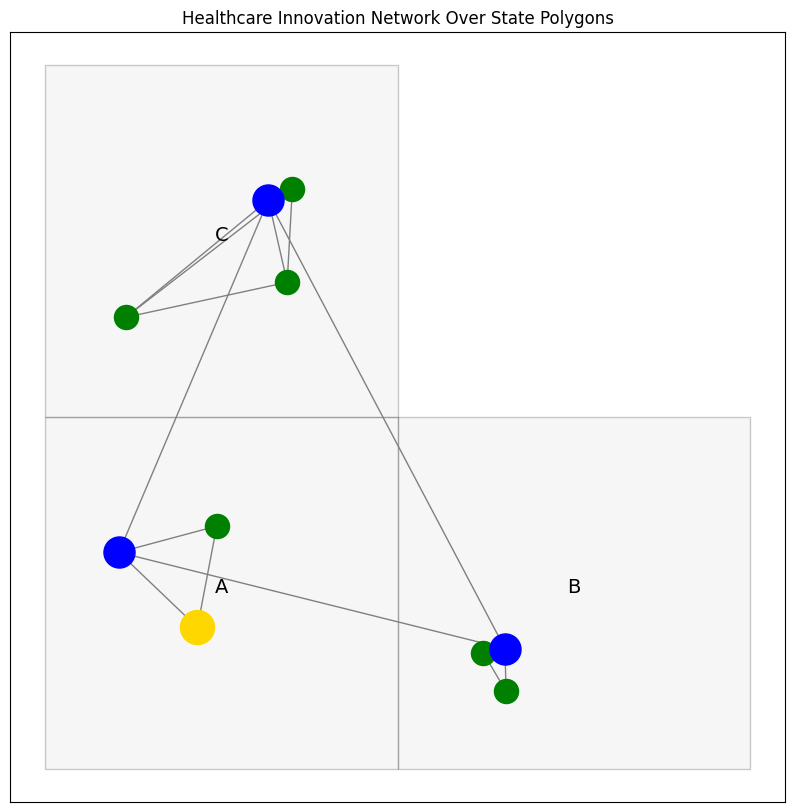

In [194]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union
fig, ax = plt.subplots(figsize=(10, 10))

# --- Plot state polygons ---
for sid, poly in STATE_POLYGONS.items():
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, alpha=0.2, fc='lightgray', ec='black')
    ax.text(poly.centroid.x, poly.centroid.y, sid, fontsize=14, ha='center')

# --- Plot network ---
positions = nx.get_node_attributes(model.network, 'pos')

# Draw edges
nx.draw_networkx_edges(model.network, positions, ax=ax, edge_color='gray')

# Draw local agents
local_nodes = [a.unique_id for a in model.local_agents]
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=local_nodes,
    node_color='green',
    node_size=300,
    ax=ax
)

# Draw state agents
state_nodes = [a.unique_id for a in model.state_agents]
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=state_nodes,
    node_color='blue',
    node_size=500,
    ax=ax
)

# Draw seed agent
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=[model.seed_agent.unique_id],
    node_color='gold',
    node_size=600,
    ax=ax
)

plt.title("Healthcare Innovation Network Over State Polygons")
plt.axis("equal")
plt.show()



This cell holds the model which consists of the geojson polygon overlays with the agent network which shall connect the agents and be the channels in which innovation flows. NEED TO INIATE SEED AGENT AND OUTPUT VISUALIZATION

Instance of the model and Display outcomes